## Credit Card Fraud Prediction

> https://www.kaggle.com/datasets/kelvinkelue/credit-card-fraud-prediction

     Autora do Notebook: Isabella Heder 

Este projeto aborda a detecção de fraudes em transações de cartão de crédito, um problema crítico devido ao alto impacto financeiro e à necessidade de proteger clientes contra cobranças indevidas.

Diferente de datasets anonimizados, este conjunto oferece uma rica variedade de atributos reais, permitindo análises mais completas e interpretação mais próxima de cenários de negócio.

##### **Objetivo**:

Desenvolver modelos de machine learning capazes de identificar transações fraudulentas com precisão, considerando o desbalanceamento dos dados.

##### **Variável alvo (target)**:
- **Is_fraud**
    - 0: transação legítima
    - 1: fraude

In [82]:
import pandas as pd
pd.set_option('display.max_columns', None)  
pd.set_option('display.width', 300)  
pd.set_option('display.max_colwidth', None)  

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

##### Dataset:
- Dataset público disponível no Kaggle (link acima)
- Contém 555.719 transações
- Não possui valores nulos
- Mistura de variáveis numéricas e categóricas
- Classe alvo altamente desbalanceada

| Variável | Tipo | Descrição |
|----------|------|-----------|
| Trans_date_trans_time | datetime | Data e hora da transação |
| Cc_num | numérico | Identificador único do cliente |
| Merchant | categórico | Nome do estabelecimento |
| Category | categórico | Tipo de transação (ex: personal, childcare) |
| Amt | numérico | Valor da transação |
| First | categórico | Primeiro nome do titular do cartão |
| Last | categórico | Sobrenome do titular do cartão |
| Gender | categórico | Gênero do titular |
| Street | categórico | Endereço do cliente |
| City | categórico | Cidade de residência |
| State | categórico | Estado de residência |
| Zip | numérico | CEP do cliente |
| Lat | numérico | Latitude da localização do cliente |
| Long | numérico | Longitude da localização do cliente |
| City_pop | numérico | População da cidade do cliente |
| Job | categórico | Profissão do cliente |
| Dob | datetime | Data de nascimento do cliente |
| Trans_num | categórico | Identificador único da transação |
| Unix_time | numérico | Timestamp da transação (formato Unix) |
| Merch_lat | numérico | Latitude do comerciante |
| Merch_long | numérico | Longitude do comerciante |


In [83]:
df = pd.read_csv('fraud-data.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             555719 non-null  int64  
 1   trans_date_trans_time  555719 non-null  object 
 2   cc_num                 555719 non-null  float64
 3   merchant               555719 non-null  object 
 4   category               555719 non-null  object 
 5   amt                    555719 non-null  float64
 6   first                  555719 non-null  object 
 7   last                   555719 non-null  object 
 8   gender                 555719 non-null  object 
 9   street                 555719 non-null  object 
 10  city                   555719 non-null  object 
 11  state                  555719 non-null  object 
 12  zip                    555719 non-null  int64  
 13  lat                    555719 non-null  float64
 14  long                   555719 non-nu

In [84]:
df.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,555719.000000,5.557190e+05,555719.000000,555719.000000,555719.000000,555719.000000,5.557190e+05,5.557190e+05,555719.000000,555719.000000,555719.000000
mean,277859.000000,4.178387e+17,69.392810,48842.628015,38.543253,-90.231325,8.822189e+04,1.380679e+09,38.542798,-90.231380,0.003860
std,160422.401459,1.309837e+18,156.745941,26855.283328,5.061336,13.721780,3.003909e+05,5.201104e+06,5.095829,13.733071,0.062008
min,0.000000,6.041621e+10,1.000000,1257.000000,20.027100,-165.672300,2.300000e+01,1.371817e+09,19.027422,-166.671575,0.000000
25%,138929.500000,1.800430e+14,9.630000,26292.000000,34.668900,-96.798000,7.410000e+02,1.376029e+09,34.755302,-96.905129,0.000000
50%,277859.000000,3.521420e+15,47.290000,48174.000000,39.371600,-87.476900,2.408000e+03,1.380762e+09,39.376593,-87.445204,0.000000
75%,416788.500000,4.635330e+15,83.010000,72011.000000,41.894800,-80.175200,1.968500e+04,1.385867e+09,41.954163,-80.264637,0.000000
max,555718.000000,4.992350e+18,22768.110000,99921.000000,65.689900,-67.950300,2.906700e+06,1.388534e+09,66.679297,-66.952026,1.000000


In [85]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,21/06/2020 12:14,2.291160e+15,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,Columbia,SC,29209,33.9659,-80.9355,333497,Mechanical engineer,19/03/1968,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,21/06/2020 12:14,3.573030e+15,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,Altonah,UT,84002,40.3207,-110.4360,302,"Sales professional, IT",17/01/1990,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,21/06/2020 12:14,3.598220e+15,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,Bellmore,NY,11710,40.6729,-73.5365,34496,"Librarian, public",21/10/1970,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,21/06/2020 12:15,3.591920e+15,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,Titusville,FL,32780,28.5697,-80.8191,54767,Set designer,25/07/1987,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,21/06/2020 12:15,3.526830e+15,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,Falmouth,MI,49632,44.2529,-85.0170,1126,Furniture designer,06/07/1955,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [86]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'], format='%d/%m/%Y %H:%M')

df['dob'] = pd.to_datetime(df['dob'], format='%d/%m/%Y')

### **Validando "saúde" do dataset**
- como visto anteriormente, o dataset não contém valores nulos

Agora vou verificar se existem valores duplicados:

In [87]:
df.duplicated().sum()

np.int64(0)

Dataset não contém valores nulos

_____________
## Distribuição das variáveis

``Variável Alvo (is_fraud)``

In [88]:
df['is_fraud'].value_counts()

is_fraud
0    553574
1      2145
Name: count, dtype: int64

In [89]:
df['is_fraud'].value_counts(normalize=True)

is_fraud
0    0.99614
1    0.00386
Name: proportion, dtype: float64

A variável alvo está extremamente desbalanceada, com poucos valores 1 (fraudes) e muitos 0 (não fraude)

``Variáveis Categóricas``

In [90]:
df['gender'].value_counts() # resultado: bem distribuido

gender
F    304886
M    250833
Name: count, dtype: int64

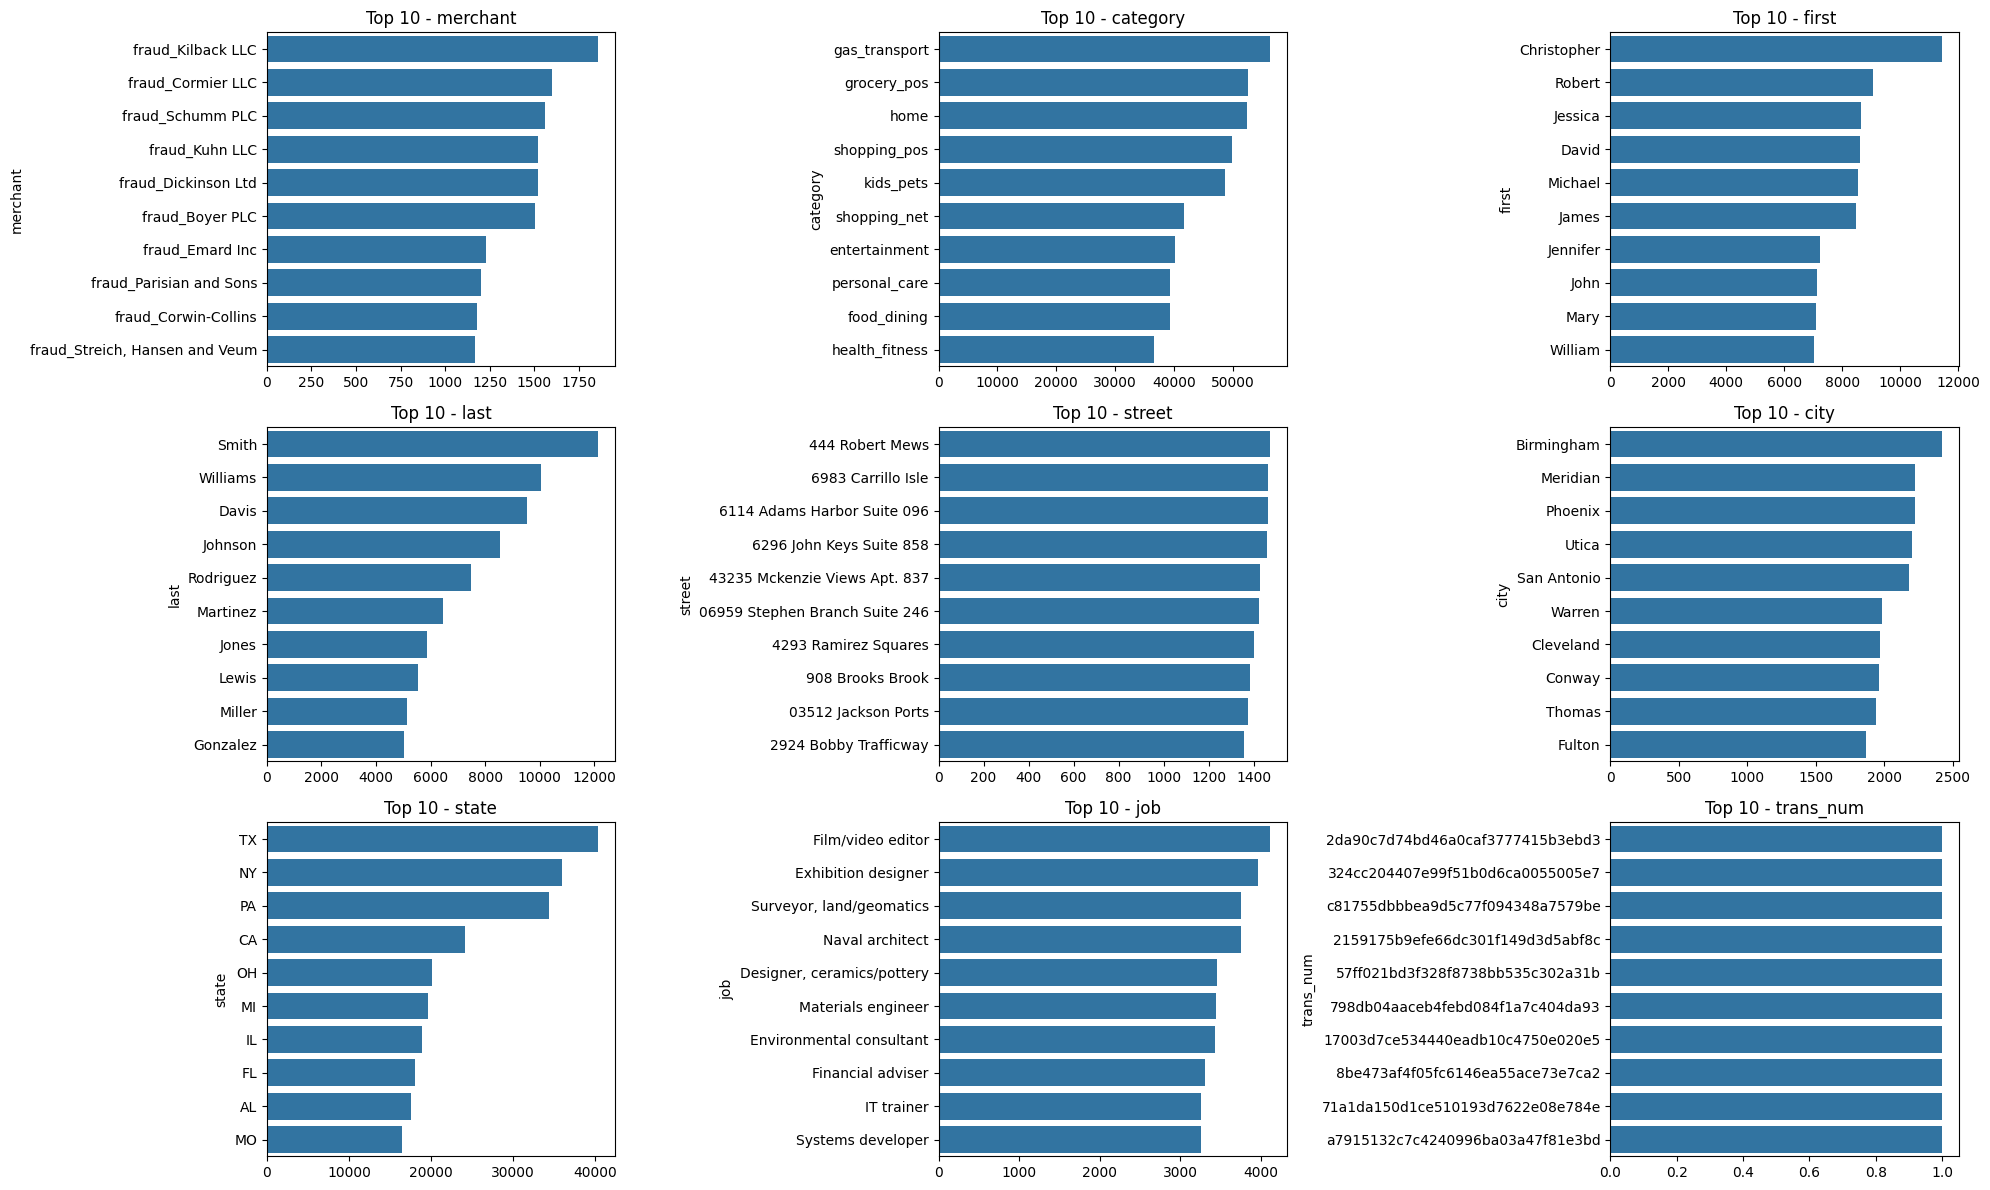

In [91]:
cols_cat = ['merchant', 'category', 'first', 'last', 'street', 'city', 'state', 'job', 'trans_num']

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(cols_cat):
    # top 10 categorias
    top_values = df[col].value_counts().head(10)
    
    sns.barplot(x=top_values.values, y=top_values.index, ax=axes[i])
    axes[i].set_title(f"Top 10 - {col}")
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

Interpretação:
- Merchant: todas as categorias começam com "fraud", por isso vou verificar se todos começam com fraud ou só os que são fraude (provavelmente todos já que fraude representa % baixa do dataset)
- first, last: nomes "comuns", pode gerar um overfit por nome
- street: as ruas em geral aparecem poucas vezes, ou seja, alta cardinalidade
- city: cidades com frequência razoável
- state: texas predomina com mais de 40k registros
- job: profissoes bem distribuidas
- trans_num: id (dropar no modelo)

Verificando Merchant:
- Sim, todos começam com 'fraud'

In [92]:
df['merchant'].str.startswith('fraud_').value_counts()

merchant
True    555719
Name: count, dtype: int64

``Variáveis contínuas``

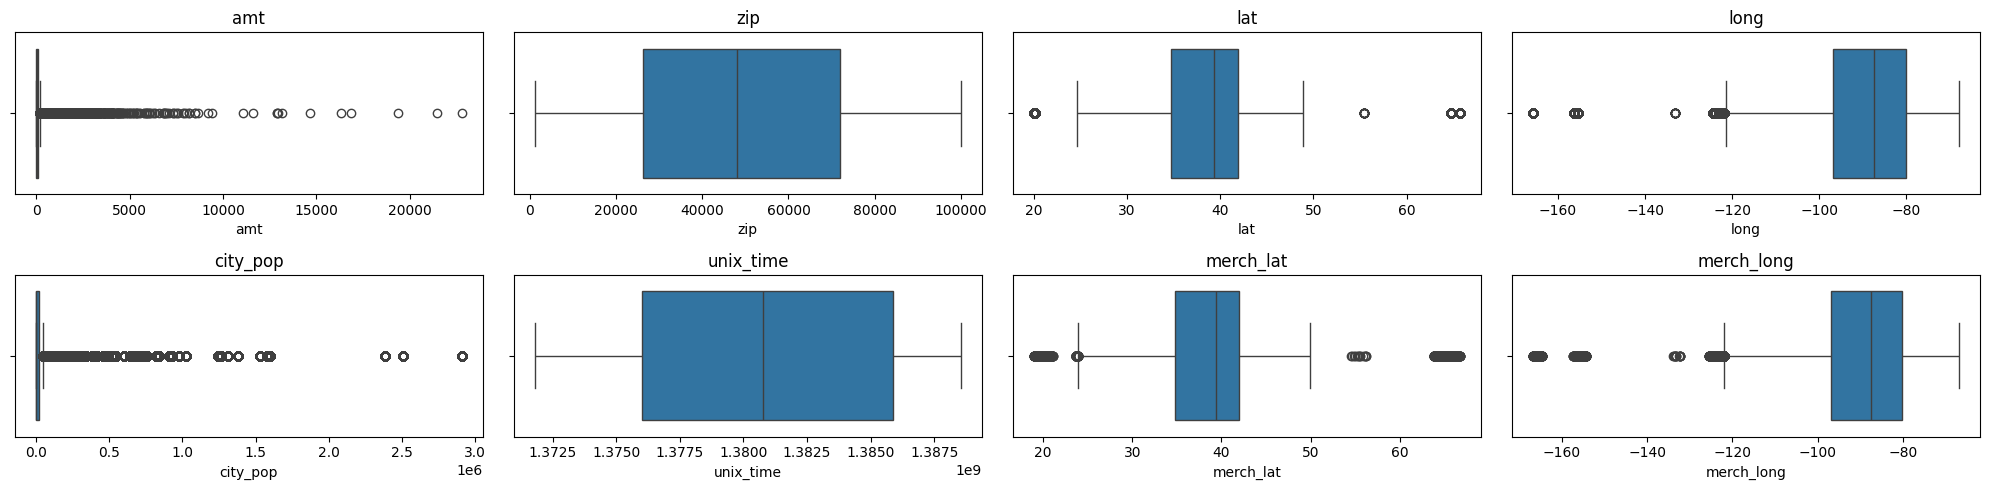

In [93]:
variaveis_continuas = ['amt', 'zip', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat', 'merch_long']
plt.figure(figsize=(20, 5))
for i, col in enumerate(variaveis_continuas):
    plt.subplot(2, 4, i + 1)
    sns.boxplot(x=col, data=df)
    plt.title(col)

plt.tight_layout()
plt.show()

Interpretação:
- amt altamente concentrada na esquerda (cauda muito longa pra direita)
- city_pop mesma coisa
- lat / long / merch_lat / merch_long: sem problemas graves de escala 

``Transformação logarítmica (amt e city_pop)``
- reduz assimetria
- torna a distribuição mais espalhada

In [94]:
df['amt_log'] = np.log1p(df['amt'])
df['city_pop_log'] = np.log1p(df['city_pop'])

Features que não são boas pro modelo:
- first: pode gerar overfit
- last: pode gerar overfit
- street: alta cardinalidade
- cc_num: id
- trans_num: id

#### Features Novas
- Criei features que talvez sejam interessantes para encontrar possíveis sazonalidades
- Hora
- Dia da Semana
- Mês
- Idade do usuário usando 'dob' e 'trans_date_trans_time'

In [95]:
df['hora'] = df['trans_date_trans_time'].dt.hour
df['dia_semana'] = df['trans_date_trans_time'].dt.dayofweek
df['mes'] = df['trans_date_trans_time'].dt.month

df['idade_user'] = (pd.to_datetime(df['trans_date_trans_time']).dt.year - df['dob'].dt.year)

### Análise de Categorias por Fraude

**``IMPORTANTE:``** 

Uma coisa que percebi: algumas categorias apresentaram taxas de fraude muito altas, chegando a 100%. No entanto, uma análise mais afundo mostrou que esses casos estavam associados a grupos com poucas observações.

Por exemplo, usuários com 18 anos (de vida na empresa) apresentaram 100% de fraude, mas existiam apenas 12 registros nessa idade e todos pertenciam ao mesmo cliente. Portanto, esse resultado não representa um padrão geral da população, mas sim um caso específico amplificado pela baixa quantidade de dados.

Por esse motivo, ``as taxas de fraude foram sempre analisadas em conjunto com a quantidade de registros de cada categoria``.

``Proporçaõ de Fraude por Gênero``
- praticamente igual
- mostra que possivelmente não seja tão relevante

In [96]:
pd.crosstab(df['gender'], df['is_fraud'], normalize='index') * 100

is_fraud,0,1
gender,,
F,99.618218,0.381782
M,99.608903,0.391097


``Proporção por categoria``
- `shopping_net` apresentou a maior taxa de fraude (~1,2%) e possui mais de 40 mil registros, indicando um padrão consistente
- `misc_net` (~1,0%) e `grocery_pos` (~0,9%) também se destacaram, com volume suficiente para sustentar o padrão
- `shopping_pos` (~0,4%) aparece em seguida, mas com uma taxa menor que as três primeiras categorias
- `gas_transport` tem uma das maiores quantidades de registros e mantém uma % de fraude acima das outras categorias

> Lembrando que as taxas de fraude foram sempre analisadas em conjunto com a quantidade de registros de cada categoria, por conta de possíveis padrões não reais por conta da baixa quantidade de registros

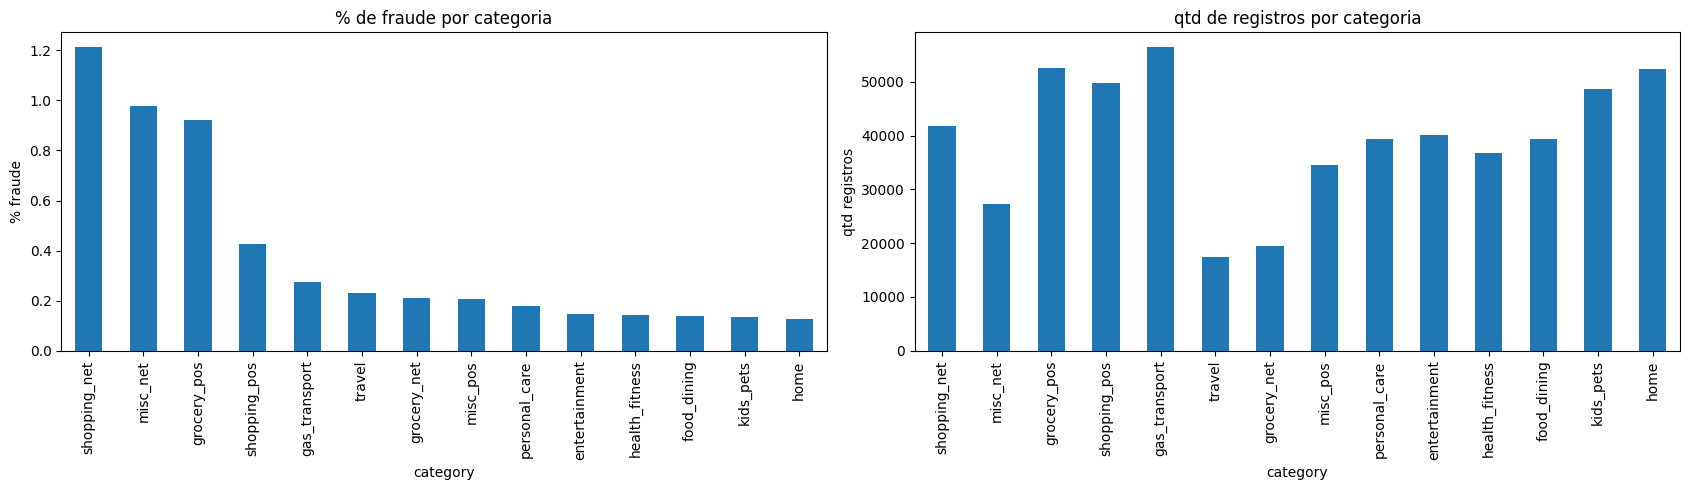

In [97]:
fraude_pct = df.groupby('category')['is_fraud'].mean() * 100
qtd_registros = df['category'].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(17, 5))
fraude_pct.sort_values(ascending=False).plot(kind='bar', ax=ax[0])
ax[0].set_title('% de fraude por categoria')
ax[0].set_ylabel('% fraude')

qtd_registros[fraude_pct.sort_values(ascending=False).index].plot(kind='bar', ax=ax[1])
ax[1].set_title('qtd de registros por categoria')
ax[1].set_ylabel('qtd registros')

plt.tight_layout()
plt.show()

``Proporção por estado``
- AK tem a maior % de fraude, mas tem poucos registros 
- CT também tem % alta de fraudes com um valor de registros maior que AK (mas ainda um valor baixo de registros)
- IN, IA, VA e KY tem % acima da média com valores de registros alta, indicando um possível padrão
- Parte dos estados com maiores proporções de fraude possui volume reduzido de observações

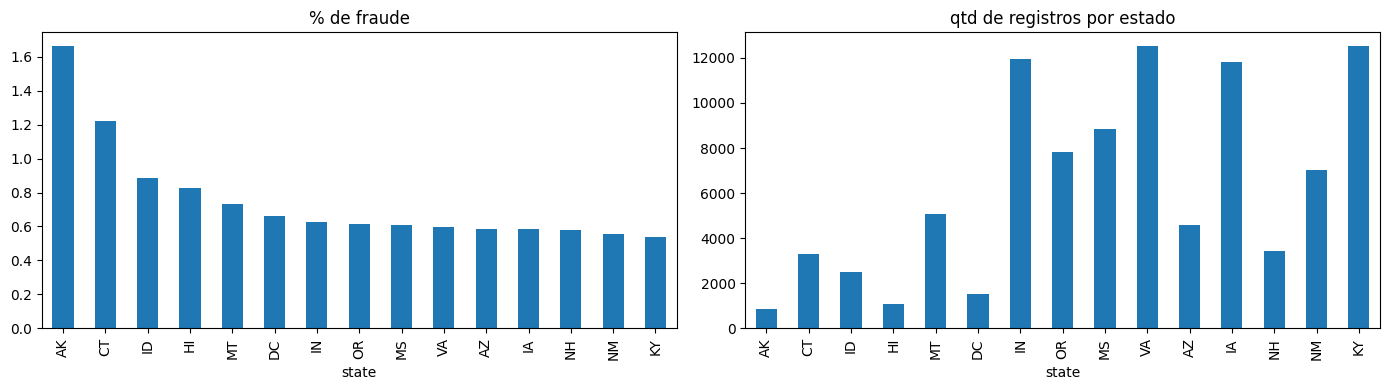

In [98]:
stats = (df.groupby('state')['is_fraud'].agg(['mean', 'count']).sort_values('mean', ascending=False).head(15))

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
(stats['mean'] * 100).plot.bar(ax=ax[0], title='% de fraude')
stats['count'].plot.bar(ax=ax[1], title='qtd de registros por estado')

plt.tight_layout()
plt.show()

``Proporção por Job``
- `Software engineer`, `Engineer, water` e `Operational investment banker` apresentaram 100% de fraude, porém possuem menos de 15 registros cada, indicando forte influência de baixa amostragem
- As outras profissões tem % entre 3% e 6%, com volume maior de observações
- `Commissioning editor` e `Visual merchandiser` se destacam pela quantidade de registros e mesma % de fraude dos outros trabalhos

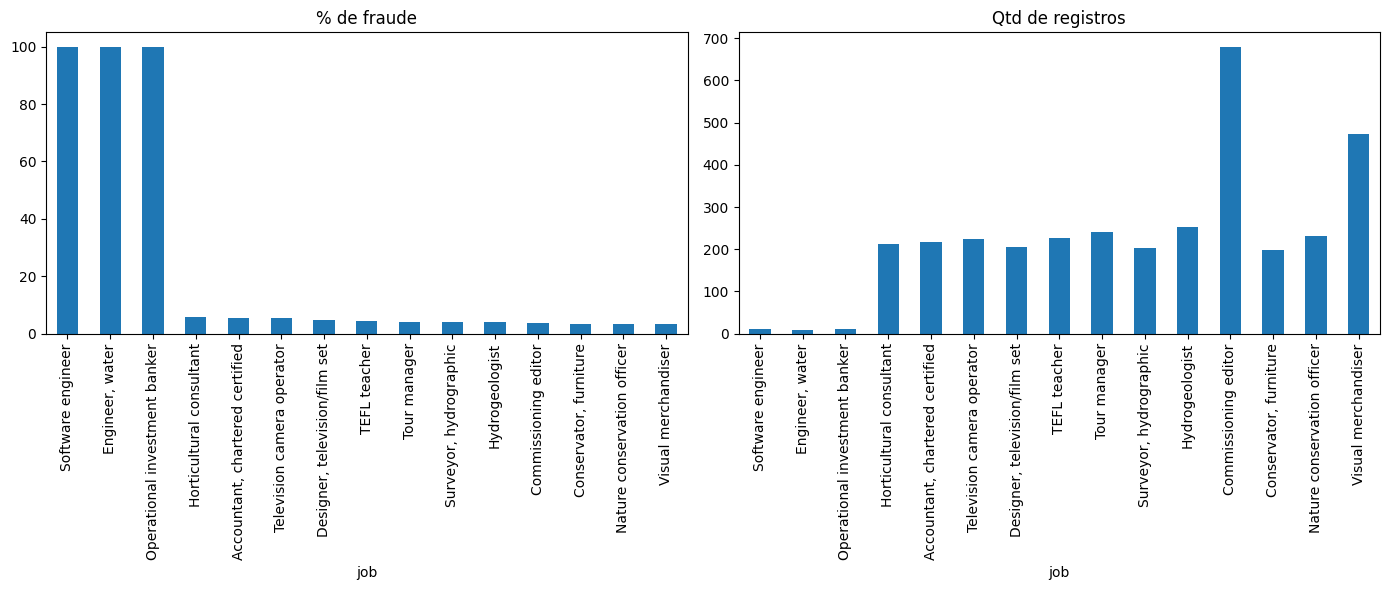

In [99]:
stats = (df.groupby('job')['is_fraud'].agg(['mean', 'count']).sort_values('mean', ascending=False).head(15))

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
(stats['mean'] * 100).plot.bar(ax=ax[0], title='% de fraude')
stats['count'].plot.bar(ax=ax[1], title='Qtd de registros')

plt.tight_layout()
plt.show()

``Fraudes por Hora``
- vejo que noite/madrugada representam os horários de pico de fraudes
- o pico é das 21h as 23h (que tem uma quantidade de registros alta) --> ``possível padrão``
- no horário comercial o volume de fraudes é baixo

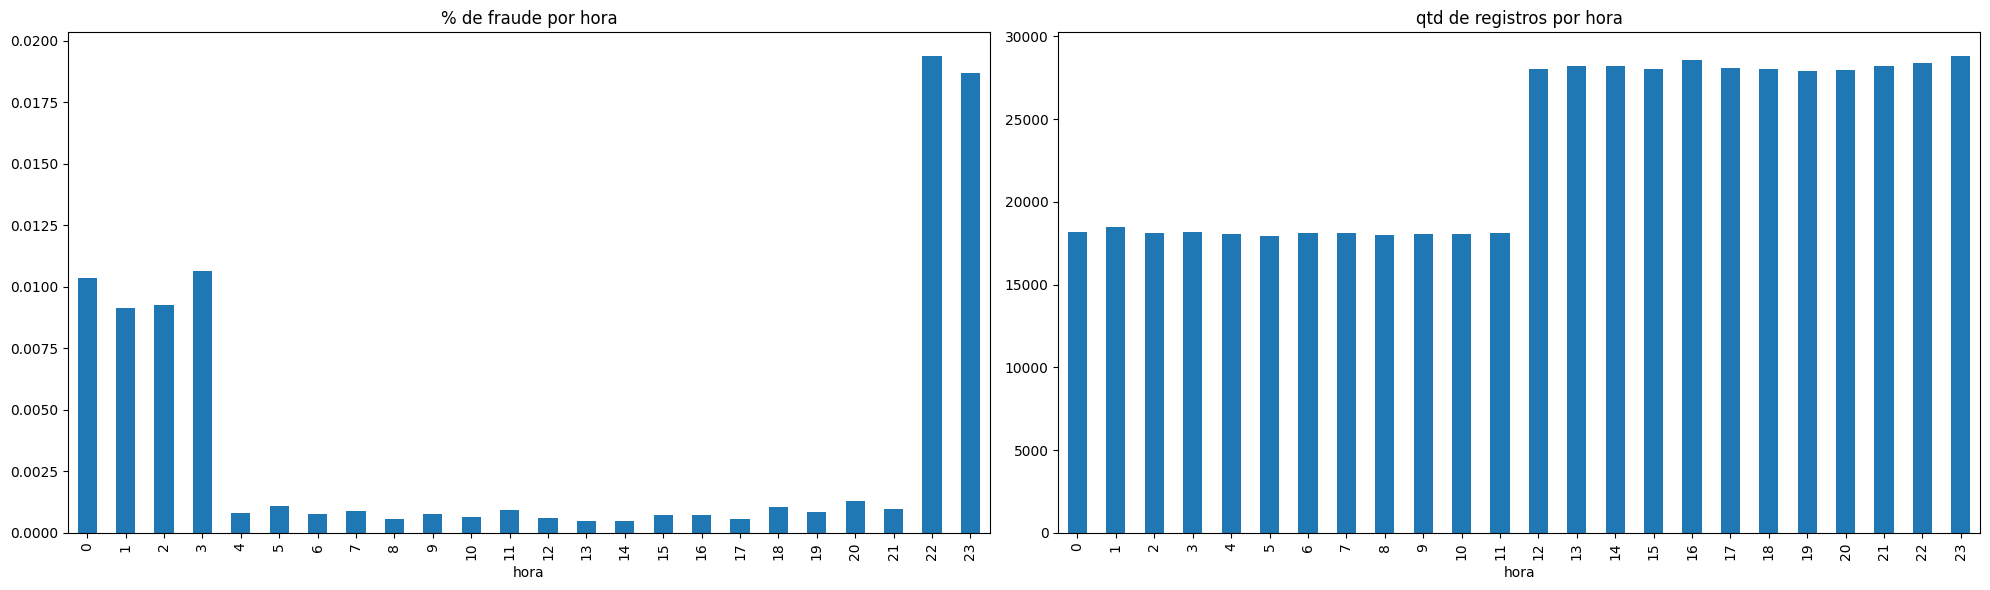

In [100]:
fig, ax = plt.subplots(1, 2, figsize=(20, 6))
df.groupby('hora')['is_fraud'].mean().plot(kind='bar', ax=ax[0], title='% de fraude por hora')
df['hora'].value_counts().sort_index().plot(kind='bar', ax=ax[1], title='qtd de registros por hora')

plt.tight_layout()
plt.show()

``Proporção por dia da semana``
- Apesar das diferenças, as taxas são baixas e muito próximas

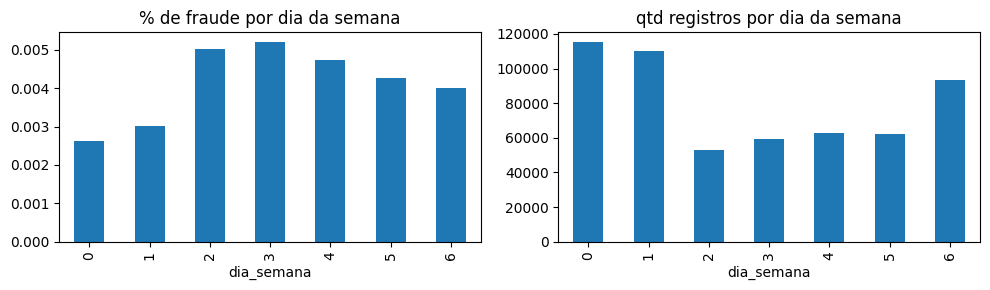

In [101]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
df.groupby('dia_semana')['is_fraud'].mean().plot(kind='bar', ax=ax[0], title='% de fraude por dia da semana')
df['dia_semana'].value_counts().sort_index().plot(kind='bar', ax=ax[1], title='qtd registros por dia da semana')

plt.tight_layout()
plt.show()

``Proporção por mês``
- Apesar das diferenças, as taxas são baixas e muito próximas

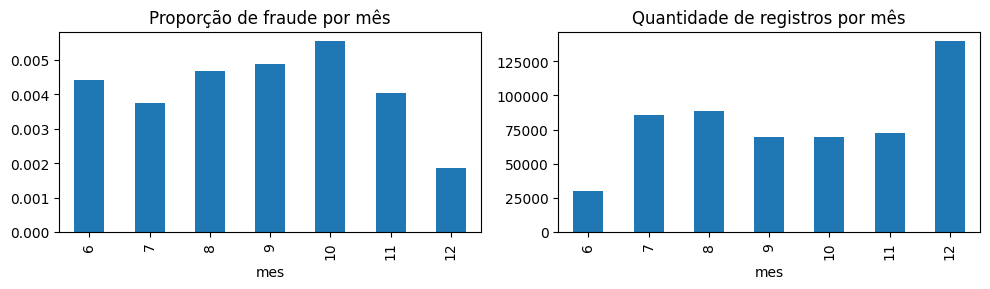

In [102]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
df.groupby('mes')['is_fraud'].mean().plot(kind='bar', ax=ax[0], title='Proporção de fraude por mês')
df['mes'].value_counts().sort_index().plot(kind='bar', ax=ax[1], title='Quantidade de registros por mês')

plt.tight_layout()
plt.show()

``Proporção por idade do usuário (tempo total de vida do cliente na empresa)``
- A idade de 18 anos apresentou uma taxa de fraude de 100%, resultado explicado pela baixa quantidade de registros (apenas 12), todos do mesmo cliente
- Para a maioria das idades, a proporção de fraude permaneceu relativamente baixa
- a idade, isoladamente, não parece ser uma das variáveis mais discriminantes para identificar fraudes

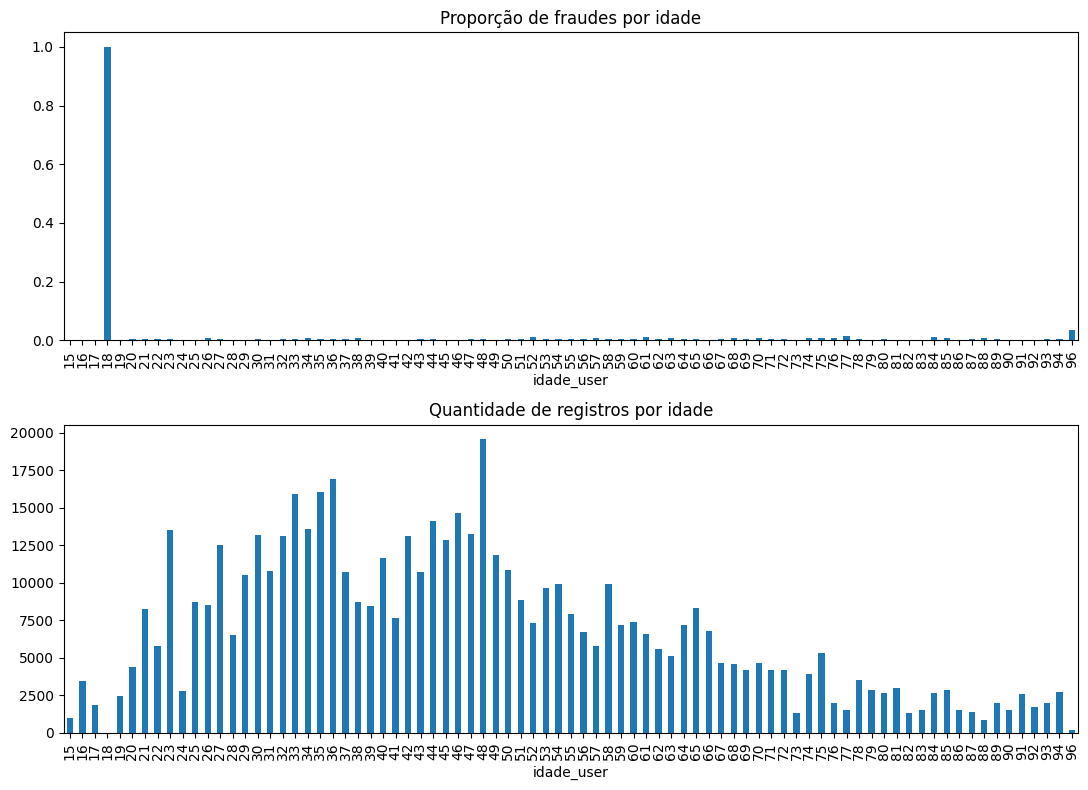

In [103]:
fig, ax = plt.subplots(2, 1, figsize=(11, 8))
df.groupby('idade_user')['is_fraud'].mean().plot(kind='bar', ax=ax[0], title='Proporção de fraudes por idade')
df['idade_user'].value_counts().sort_index().plot(kind='bar', ax=ax[1], title='Quantidade de registros por idade')

plt.tight_layout()
plt.show()

``Proporção por corte de Valor``
- A faixa de maior valor (acima de $135) tem uma % de fraude superior às demais, chegando perto de 3%
- As outras faixas apresentaram taxas menores, em geral abaixo de 0,5%

C:\Users\IsabellaHeder\AppData\Local\Temp\ipykernel_8368\925709186.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.qcut(df['amt'], 10))['is_fraud'].mean().plot(kind='bar', ax=ax[0], title='Proporção de fraude por faixa de valor')


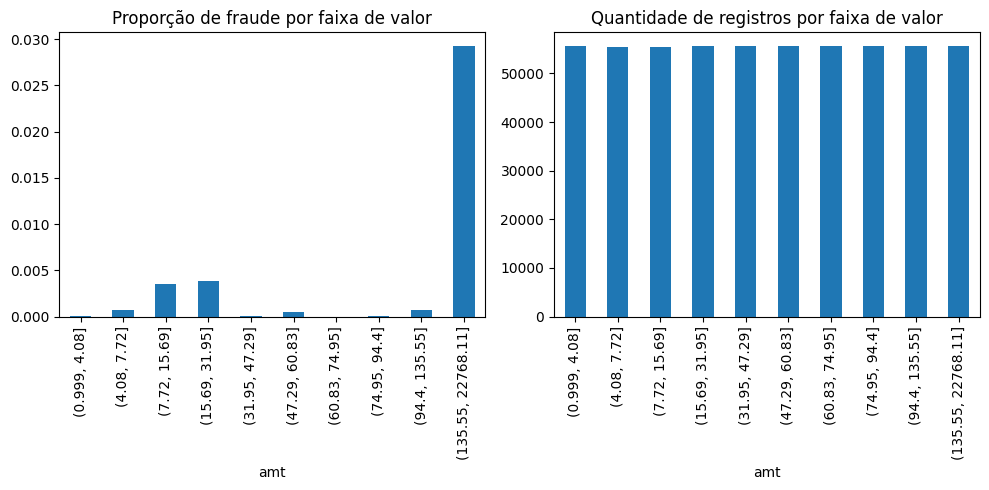

In [104]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
df.groupby(pd.qcut(df['amt'], 10))['is_fraud'].mean().plot(kind='bar', ax=ax[0], title='Proporção de fraude por faixa de valor')
pd.qcut(df['amt'], 10).value_counts().sort_index().plot(kind='bar', ax=ax[1], title='Quantidade de registros por faixa de valor')

plt.tight_layout()
plt.show()

### Correlação entre variáveis
- `amt` foi a variável com maior correlação com a target
- lembrando que baixa correlação não significa ausência de poder preditivo
- por questões de multicolinearidade eu escolhi retirar a coluna zip

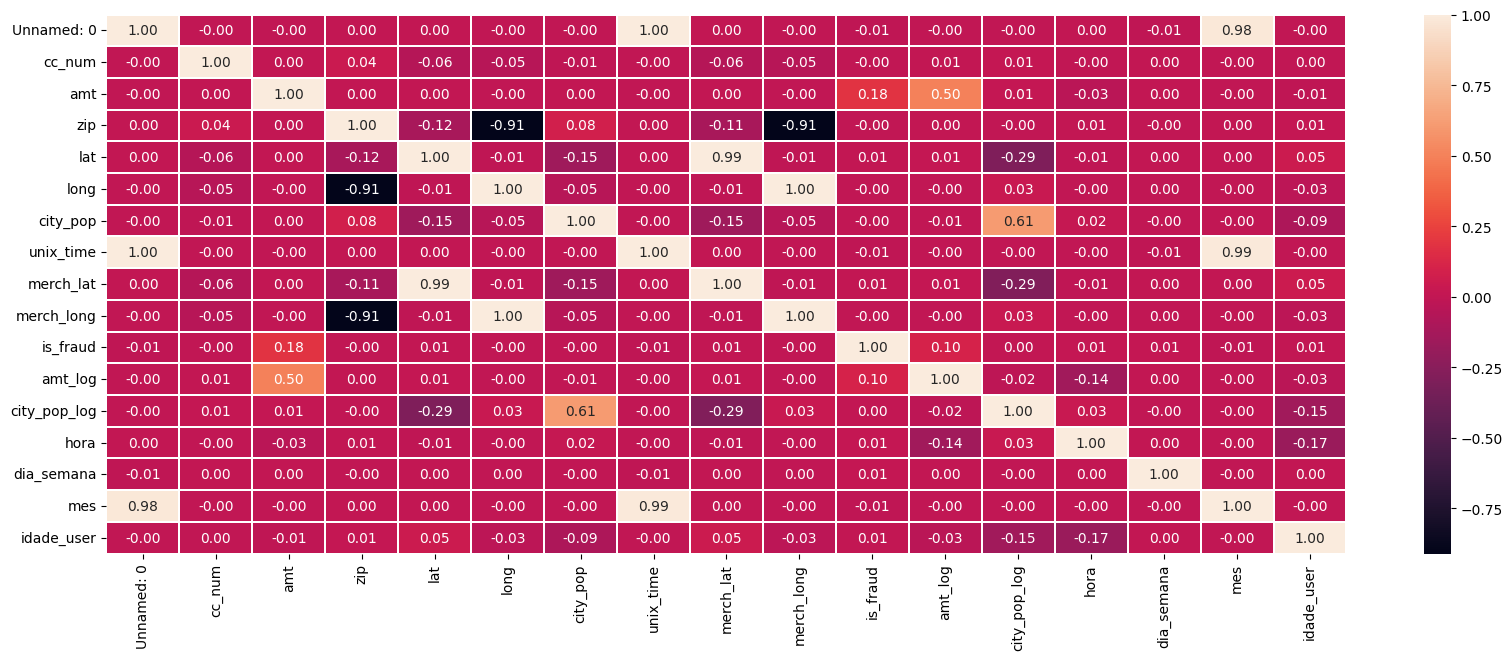

In [105]:
matriz_correlacao = df.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(20, 7))
sns.heatmap(matriz_correlacao, annot = True, fmt = '.2f', linewidths = 0.2)
plt.show()

### Modelagem
- Vou iniciar transformando variáveis categóricas em numéricas
- Depois vou fazer undersampling para balancear as categorias da target
- Depois vou fazer um benchmark de modelos
- Depois vou terminar selecionando e treinando o modelo final

``Retirando colunas desnecessárias para o modelo``

In [106]:
df.drop(columns=['Unnamed: 0', 'trans_date_trans_time', 'first', 'last', 'street', 'cc_num', 'trans_num', 'dob', 'unix_time', 'amt', 'city_pop', 'zip'], inplace=True)

``Transformando valores categóricos``
- 2095 colunas para um dataset de 550k de linhas
- bool(2080), float64(7), int32(4), int64(3)

In [107]:
colunas_dummy = ['merchant', 'category', 'gender', 'city', 'state', 'job']

df2 = pd.get_dummies(df, columns=colunas_dummy, drop_first=True)

In [108]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Columns: 2091 entries, lat to job_Writer
dtypes: bool(2080), float64(6), int32(4), int64(1)
memory usage: 1.1 GB


``Undersampling``
- Por conta da target ser extremamente desbalanceada, eu utilizei undersampling para realizar o balanceamento das categorias (1 e 0)
- O dataset original possuía uma quantidade extremamente maior de registros do que o df2_under (pós undersampling), por isso:
    - eu realizei o treinamento, vi o resultado e fiz um treinamento do modelo com os dados que não entraram no under, para poder entender se o modelo estava generalizando bem e não tinha causado um possível overfit

In [109]:
# tamanho da menor classe
min_class_size = df2['is_fraud'].value_counts().min()
# undersampling
df2_under = (df2.groupby('is_fraud').sample(n=min_class_size, random_state=42).reset_index(drop=True))

# conferindo
print(df2_under['is_fraud'].value_counts())

is_fraud
0    2145
1    2145
Name: count, dtype: int64


In [110]:
X = df2_under.drop(['is_fraud'], axis=1)
y = df2_under['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

``Benchmark``

Vou testar utilizar 3 modelos diferentes:
- Logistic Regression
- XGBClassifier
- Random Forest Classifier

     Logistic Regression 
- Utilzei standard scaler para diminuir a escala
- Utilizei class_weight='balanced' para lidar com o desbalanceamento da variável alvo (da mais importância para fraude --> 1)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=5000, class_weight='balanced', random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:,1]

     Random Forest Classifier 
- não foi necessário usar normalização porque modelos de árvore não dependem de escala
- class_weight='balanced' para compensar o desbalanceamento, evitando viés

In [112]:
rf = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

     XGBClassifier 
- primeiro calculei o parâmetro (scale_pos_weight) que ajusta o peso da classe positiva (fraude), fiz isso para melhorar o aprendizado já que o dataset tá desbalanceado (aqui não tem a opção de class_weight = balanced)
- novamente, não normalizei porque modelos de boosting (em árvores) não são sensíveis a escala

In [113]:
scale = len(y_train[y_train==0]) / len(y_train[y_train==1])

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='logloss')

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

     Avaliação 

Avaliação vai ser feita baseada em recall (fraude), precision (fraude), f1-score e auc-pr

In [114]:
from sklearn.metrics import classification_report
def aval_bench(name, y_test, y_pred, y_prob):
    print(f"\n{name}")
    print(classification_report(y_test, y_pred))
    print("AUC-PR:", average_precision_score(y_test, y_prob))

aval_bench("Logistic Regression", y_test, y_pred_lr, y_prob_lr)
aval_bench("Random Forest", y_test, y_pred_rf, y_prob_rf)
aval_bench("XGBoost", y_test, y_pred_xgb, y_prob_xgb)


Logistic Regression
              precision    recall  f1-score   support

           0       0.85      0.82      0.83       429
           1       0.83      0.86      0.84       429

    accuracy                           0.84       858
   macro avg       0.84      0.84      0.84       858
weighted avg       0.84      0.84      0.84       858

AUC-PR: 0.9055912585653731

Random Forest
              precision    recall  f1-score   support

           0       0.80      0.96      0.88       429
           1       0.95      0.77      0.85       429

    accuracy                           0.86       858
   macro avg       0.88      0.86      0.86       858
weighted avg       0.88      0.86      0.86       858

AUC-PR: 0.9610557037098788

XGBoost
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       429
           1       0.97      0.97      0.97       429

    accuracy                           0.97       858
   macro avg       0.97      

In [115]:
resultados = []

def benchmark(nome, y_test, y_pred, y_prob):
    report = classification_report(y_test, y_pred, output_dict=True)
    
    resultados.append({
        "modelo": nome,
        "precisao (fraude)": report['1']['precision'],
        "recall (fraude)": report['1']['recall'],
        "F1 (fraude)": report['1']['f1-score'],
        "auc-pr": average_precision_score(y_test, y_prob)
    })

benchmark("Logistic Regression", y_test, y_pred_lr, y_prob_lr)
benchmark("Random Forest", y_test, y_pred_rf, y_prob_rf)
benchmark("XGBoost", y_test, y_pred_xgb, y_prob_xgb)

results_df = pd.DataFrame(resultados)
results_df

,modelo,precisao (fraude),recall (fraude),F1 (fraude),auc-pr
0,Logistic Regression,0.825112,0.857809,0.841143,0.905591
1,Random Forest,0.950867,0.766900,0.849032,0.961056
2,XGBoost,0.967517,0.972028,0.969767,0.993690


O **XGBoost** apresentou o melhor equilíbrio entre detecção de fraudes e controle de falsos positivos

Considerando que o problema tem target desbalanceada, o **AUC-PR** foi a métrica mais relevante para comparação dos modelos

``XGBoost foi selecionado como modelo final para a detecção de fraude``

In [116]:
from sklearn.metrics import precision_score, accuracy_score, confusion_matrix, roc_auc_score, recall_score, classification_report

def avaliar_modelo(y_test, y_pred):
    print(f"acuracia: {accuracy_score(y_test, y_pred)}")
    print(f"precisao: {precision_score(y_test, y_pred)}")
    print(f"recall: {recall_score(y_test, y_pred)}")
    cm = confusion_matrix(y_test, y_pred)
    print(f"roc auc: {roc_auc_score(y_test, y_pred)}")
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.show()

### Modelo Final

XGBClassifier
- O modelo final apresentou um desempenho muito muito bom, com recall de 0.97 e demais métricas acima de 0.95
- Por ser um dataset fruto de undersampling, vou verificar se o modelo está generalizando bem, ou se só pegou os padrões dessa quantidade pequena de dados

acuracia: 0.9696969696969697
precisao: 0.9675174013921114
recall: 0.972027972027972
roc auc: 0.9696969696969697


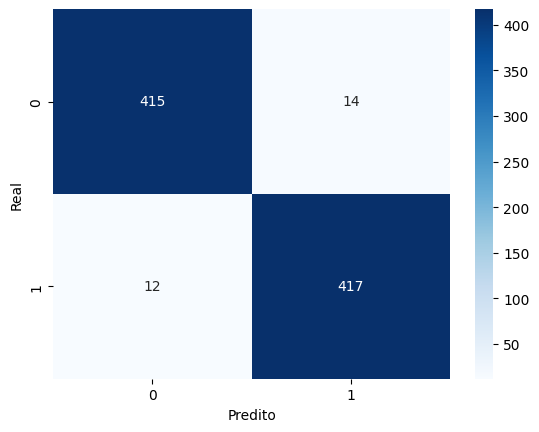

In [117]:
xgb_final = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='logloss')

xgb_final.fit(X_train, y_train)
y_prob = xgb_final.predict_proba(X_test)[:,1]
y_pred = xgb_final.predict(X_test)

avaliar_modelo(y_test, y_pred)

In [118]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97       429
           1       0.97      0.97      0.97       429

    accuracy                           0.97       858
   macro avg       0.97      0.97      0.97       858
weighted avg       0.97      0.97      0.97       858



### Testando Generalização do Modelo
Como dito anteriormente, o dataset usado pelo modelo final era fruto de undersampling, e isso reduziu os dados de 550k para menos de 4k...
- Por isso, realizei o treinamento (com o mesmo modelo), nos dados que ficaram pra fora do undersampling. 
- Eu fiz isso para ver se o modelo seria capaz de captar padrões de outros dados (generalizar bem), sem ser os que entraram no under

In [ ]:
min_class_size = df2['is_fraud'].value_counts().min()
df_under = (df2.groupby('is_fraud', group_keys=False).sample(n=min_class_size, random_state=42))

# registros removidos pelo undersample
df_fora = df2.drop(df_under.index)
print(df_fora['is_fraud'].value_counts())

is_fraud
0    551429
Name: count, dtype: int64


Avaliação do modelo de "restos"
- Ele conseguiu generalizar bem, mostrando que o modelo, mesmo treinado com poucos dados, conseguiu captar os padrões e coseguiu aplicar isso nos dados que ficaram de fora

In [120]:
X_fora = df_fora.drop(columns=['is_fraud'])
y_fora = df_fora['is_fraud']

pred = xgb_final.predict(X_fora)

from sklearn.metrics import classification_report

print(classification_report(y_fora, pred))

              precision    recall  f1-score   support

           0       1.00      0.97      0.98    551429
           1       0.00      0.00      0.00         0

    accuracy                           0.97    551429
   macro avg       0.50      0.48      0.49    551429
weighted avg       1.00      0.97      0.98    551429



c:\Users\IsabellaHeder\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\IsabellaHeder\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\IsabellaHeder\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

c:\Users\IsabellaHeder\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


acuracia: 0.9694774848620584
precisao: 0.0
recall: 0.0
roc auc: nan


c:\Users\IsabellaHeder\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


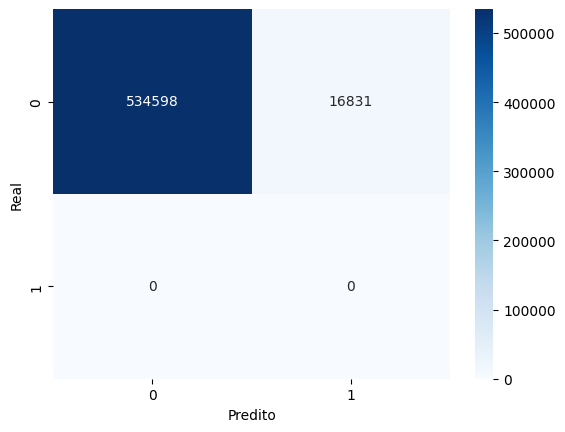

In [121]:
avaliar_modelo(y_fora, pred)

FIM

Muito obrigada!